In [1]:
%%time
%matplotlib inline
import rioxarray
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import importlib 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression

CPU times: total: 250 ms
Wall time: 3.69 s


In [2]:
vh_data  = gpd.read_file('.\input\Lua2v_VH_tot\Lua2v_VH_tot.shp')
# Chọn các cột giá trị theo thời gian
columns_months = [
    'STVH202223', 'STVH2022_1', 'STVH2022_2', 'STVH2022_3', 
    'STVH2022_4', 'STVH2022_5', 'STVH2022_6', 'STVH2022_7', 
    'STVH2022_8', 'STVH2022_9', 'STVH202210', 'STVH202211', 'STVH202212'
]

# Tính trung bình tại mỗi thời điểm
mean_trend_vh = vh_data[columns_months].mean(axis=0)
std_trend = vh_data[columns_months].std()
mean_trend_vh

STVH202223   -17.560788
STVH2022_1   -24.005382
STVH2022_2   -20.492405
STVH2022_3   -18.769568
STVH2022_4   -16.602890
STVH2022_5   -16.711382
STVH2022_6   -20.045402
STVH2022_7   -23.251152
STVH2022_8   -22.045732
STVH2022_9   -21.169287
STVH202210   -17.259067
STVH202211   -18.341248
STVH202212   -17.534327
dtype: float64

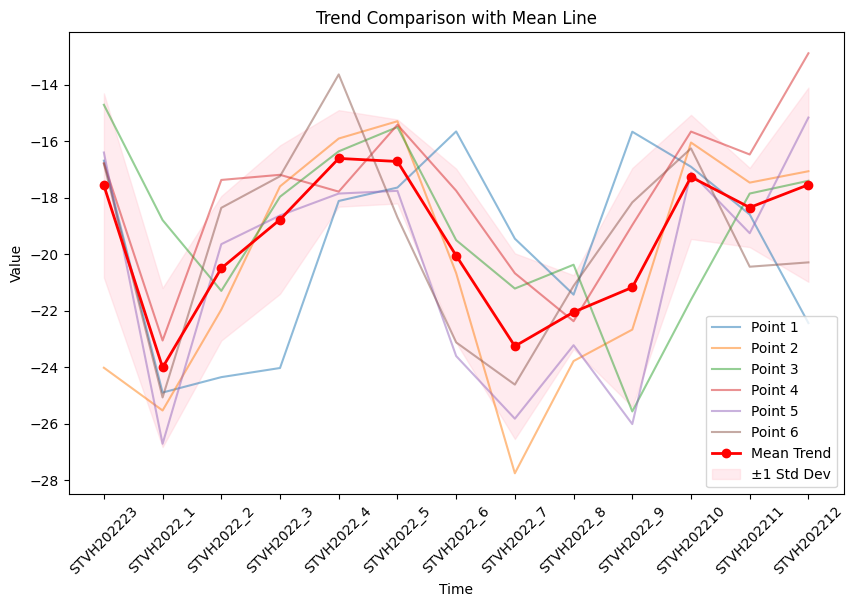

In [3]:
plt.figure(figsize=(10, 6))

# Vẽ từng đường của từng điểm
for index, row in vh_data.iterrows():
    plt.plot(columns_months, row[columns_months], label=f"Point {index+1}", alpha=0.5)

# Vẽ đường trung bình
plt.plot(mean_trend_vh.index, mean_trend_vh.values, color='red', marker='o', linewidth=2, label="Mean Trend")


plt.fill_between(
    columns_months,
    mean_trend_vh - std_trend,
    mean_trend_vh + std_trend,
    color='pink',
    alpha=0.3,
    label="±1 Std Dev"
)


plt.legend()
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.xlabel("Time")
plt.title("Trend Comparison with Mean Line")
plt.show()

In [4]:
vh_data = vh_data[columns_months]
vh_data

,STVH202223,STVH2022_1,STVH2022_2,STVH2022_3,STVH2022_4,STVH2022_5,STVH2022_6,STVH2022_7,STVH2022_8,STVH2022_9,STVH202210,STVH202211,STVH202212
0,-16.68230,-24.89299,-24.34774,-24.02413,-18.10999,-17.63466,-15.64754,-19.44482,-21.42665,-15.65790,-16.89941,-18.58814,-22.43330
1,-24.01494,-25.52887,-21.95634,-17.59287,-15.89884,-15.28673,-20.66421,-27.75158,-23.77824,-22.66485,-16.03965,-17.45979,-17.05682
2,-14.70460,-18.78688,-21.29322,-17.95999,-16.35238,-15.49346,-19.49691,-21.21115,-20.36739,-25.56118,-21.60650,-17.84680,-17.39517
3,-16.77309,-23.05057,-17.36561,-17.18334,-17.77940,-15.41142,-17.74660,-20.66828,-22.36794,-18.96240,-15.65324,-16.46400,-12.88019
4,-16.39377,-26.70671,-19.63932,-18.62244,-17.84767,-17.75087,-23.60003,-25.81900,-23.21648,-26.00979,-17.10725,-19.25063,-15.15625
5,-16.79603,-25.06627,-18.35220,-17.23464,-13.62906,-18.69115,-23.11712,-24.61208,-21.11769,-18.15960,-16.24835,-20.43813,-20.28423


In [5]:
filtered_arrays = np.load('./input/l2v.npy')
# columns_months = [f"Month_{i+1}" for i in range(13)]  # Tạo tên cột: Month_1, Month_2, ..., Month_13
# ndvi_data = pd.DataFrame(filtered_arrays, columns=columns_months)
ndvi_data = filtered_arrays
ndvi_data = pd.DataFrame(filtered_arrays, columns=columns_months)
ndvi_data


,STVH202223,STVH2022_1,STVH2022_2,STVH2022_3,STVH2022_4,STVH2022_5,STVH2022_6,STVH2022_7,STVH2022_8,STVH2022_9,STVH202210,STVH202211,STVH202212
0,-0.122940,-0.049689,0.121701,0.540699,0.935288,0.761738,0.181170,0.273349,0.780973,0.851385,0.501213,0.016974,-0.016949
1,-0.105294,-0.057187,0.105644,0.535918,0.936492,0.761525,0.183056,0.286041,0.787919,0.850620,0.500821,0.012696,-0.029619
2,-0.143524,-0.049482,0.116654,0.526046,0.929833,0.759006,0.172808,0.277564,0.784459,0.833740,0.493257,0.013616,-0.016898
3,-0.132962,-0.050193,0.118343,0.518698,0.931258,0.760083,0.175035,0.272734,0.785911,0.835963,0.505085,0.026909,-0.011615
4,-0.130599,-0.050305,0.114993,0.499736,0.935484,0.777601,0.167595,0.383105,0.790184,0.849987,0.525195,0.040222,-0.029090
5,-0.154044,-0.042340,0.122581,0.494384,0.936412,0.786240,0.169626,0.382757,0.800135,0.862661,0.555161,0.041579,-0.012696
6,-0.123832,-0.055300,0.118620,0.633013,0.936516,0.734238,0.178354,0.298329,0.776058,0.836636,0.451255,0.047091,-0.015665
7,-0.104612,-0.059592,0.106082,0.617073,0.939981,0.737161,0.175619,0.298610,0.783112,0.839222,0.469411,0.034294,-0.013864
8,-0.110862,-0.054180,0.112686,0.611998,0.933202,0.729078,0.190473,0.300563,0.773556,0.819751,0.482067,0.046528,-0.013858
9,-0.138686,-0.054432,0.119371,0.599978,0.932873,0.742580,0.184617,0.310385,0.790180,0.821343,0.515424,0.032544,-0.010145


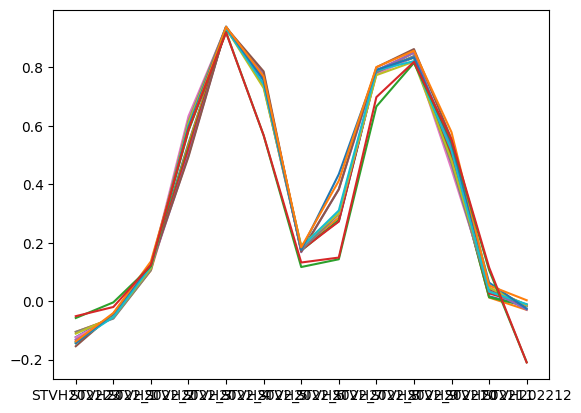

In [6]:
# Hiển thị dữ liệu ban đầu
for row, column in ndvi_data.iterrows():
    plt.plot(columns_months, column)
# plt.plot(vh_data, label="VH thực")
plt.show()

In [7]:
t = np.linspace(0, 2*np.pi, 10)
t

array([0.        , 0.6981317 , 1.3962634 , 2.0943951 , 2.7925268 ,
       3.4906585 , 4.1887902 , 4.88692191, 5.58505361, 6.28318531])

In [8]:
ndvi = ndvi_data.iloc[:, 2:]
ndvi

,STVH2022_2,STVH2022_3,STVH2022_4,STVH2022_5,STVH2022_6,STVH2022_7,STVH2022_8,STVH2022_9,STVH202210,STVH202211,STVH202212
0,0.121701,0.540699,0.935288,0.761738,0.181170,0.273349,0.780973,0.851385,0.501213,0.016974,-0.016949
1,0.105644,0.535918,0.936492,0.761525,0.183056,0.286041,0.787919,0.850620,0.500821,0.012696,-0.029619
2,0.116654,0.526046,0.929833,0.759006,0.172808,0.277564,0.784459,0.833740,0.493257,0.013616,-0.016898
3,0.118343,0.518698,0.931258,0.760083,0.175035,0.272734,0.785911,0.835963,0.505085,0.026909,-0.011615
4,0.114993,0.499736,0.935484,0.777601,0.167595,0.383105,0.790184,0.849987,0.525195,0.040222,-0.029090
5,0.122581,0.494384,0.936412,0.786240,0.169626,0.382757,0.800135,0.862661,0.555161,0.041579,-0.012696
6,0.118620,0.633013,0.936516,0.734238,0.178354,0.298329,0.776058,0.836636,0.451255,0.047091,-0.015665
7,0.106082,0.617073,0.939981,0.737161,0.175619,0.298610,0.783112,0.839222,0.469411,0.034294,-0.013864
8,0.112686,0.611998,0.933202,0.729078,0.190473,0.300563,0.773556,0.819751,0.482067,0.046528,-0.013858
9,0.119371,0.599978,0.932873,0.742580,0.184617,0.310385,0.790180,0.821343,0.515424,0.032544,-0.010145


In [9]:
vh = vh_data.iloc[:,2:]
vh

,STVH2022_2,STVH2022_3,STVH2022_4,STVH2022_5,STVH2022_6,STVH2022_7,STVH2022_8,STVH2022_9,STVH202210,STVH202211,STVH202212
0,-24.34774,-24.02413,-18.10999,-17.63466,-15.64754,-19.44482,-21.42665,-15.65790,-16.89941,-18.58814,-22.43330
1,-21.95634,-17.59287,-15.89884,-15.28673,-20.66421,-27.75158,-23.77824,-22.66485,-16.03965,-17.45979,-17.05682
2,-21.29322,-17.95999,-16.35238,-15.49346,-19.49691,-21.21115,-20.36739,-25.56118,-21.60650,-17.84680,-17.39517
3,-17.36561,-17.18334,-17.77940,-15.41142,-17.74660,-20.66828,-22.36794,-18.96240,-15.65324,-16.46400,-12.88019
4,-19.63932,-18.62244,-17.84767,-17.75087,-23.60003,-25.81900,-23.21648,-26.00979,-17.10725,-19.25063,-15.15625
5,-18.35220,-17.23464,-13.62906,-18.69115,-23.11712,-24.61208,-21.11769,-18.15960,-16.24835,-20.43813,-20.28423


In [10]:

vh_data = vh.values
vh_data

array([[-24.34774, -24.02413, -18.10999, -17.63466, -15.64754, -19.44482,
        -21.42665, -15.6579 , -16.89941, -18.58814, -22.4333 ],
       [-21.95634, -17.59287, -15.89884, -15.28673, -20.66421, -27.75158,
        -23.77824, -22.66485, -16.03965, -17.45979, -17.05682],
       [-21.29322, -17.95999, -16.35238, -15.49346, -19.49691, -21.21115,
        -20.36739, -25.56118, -21.6065 , -17.8468 , -17.39517],
       [-17.36561, -17.18334, -17.7794 , -15.41142, -17.7466 , -20.66828,
        -22.36794, -18.9624 , -15.65324, -16.464  , -12.88019],
       [-19.63932, -18.62244, -17.84767, -17.75087, -23.60003, -25.819  ,
        -23.21648, -26.00979, -17.10725, -19.25063, -15.15625],
       [-18.3522 , -17.23464, -13.62906, -18.69115, -23.11712, -24.61208,
        -21.11769, -18.1596 , -16.24835, -20.43813, -20.28423]])

In [11]:
ndvi_data = ndvi.values
ndvi_data

array([[ 0.1217009 ,  0.5406991 ,  0.93528813,  0.76173824,  0.18117008,
         0.27334937,  0.78097296,  0.8513847 ,  0.5012132 ,  0.01697416,
        -0.01694913],
       [ 0.10564394,  0.5359178 ,  0.93649197,  0.76152456,  0.18305641,
         0.28604063,  0.78791875,  0.85061955,  0.5008211 ,  0.01269604,
        -0.02961922],
       [ 0.11665443,  0.5260455 ,  0.9298333 ,  0.7590058 ,  0.17280811,
         0.27756402,  0.78445894,  0.8337399 ,  0.4932568 ,  0.01361573,
        -0.01689823],
       [ 0.1183432 ,  0.5186983 ,  0.9312577 ,  0.7600833 ,  0.17503536,
         0.2727336 ,  0.7859107 ,  0.8359631 ,  0.5050847 ,  0.02690904,
        -0.01161482],
       [ 0.11499273,  0.49973643,  0.9354838 ,  0.7776015 ,  0.16759488,
         0.38310495,  0.79018354,  0.84998655,  0.52519536,  0.04022187,
        -0.02908954],
       [ 0.12258065,  0.49438378,  0.93641186,  0.7862395 ,  0.16962585,
         0.38275698,  0.80013496,  0.8626611 ,  0.5551611 ,  0.04157862,
        -0.012

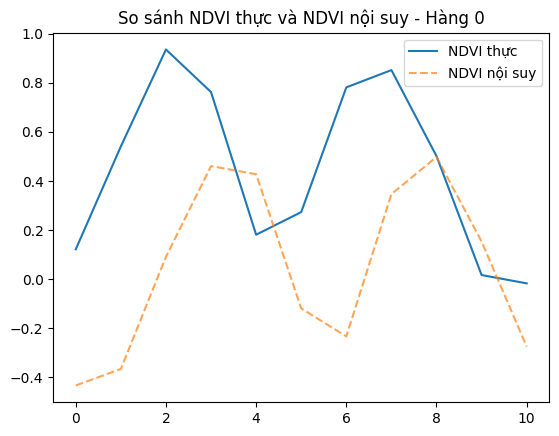

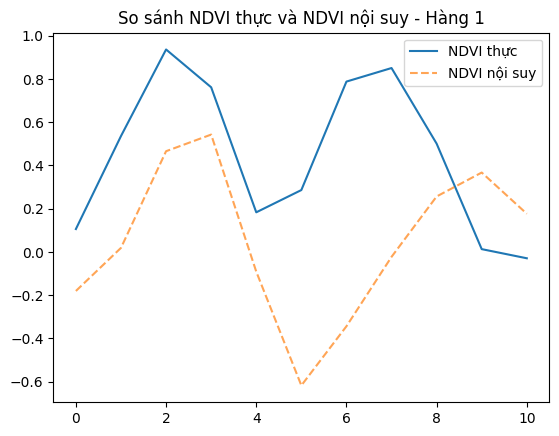

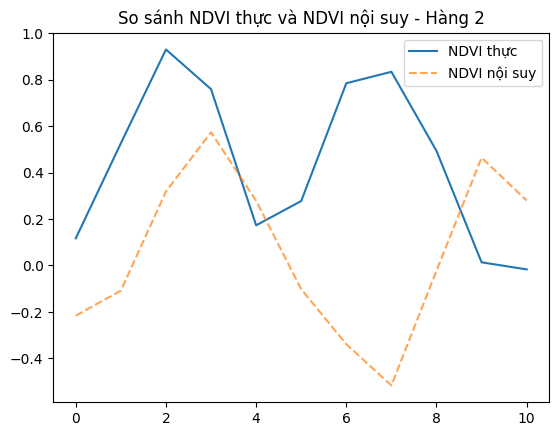

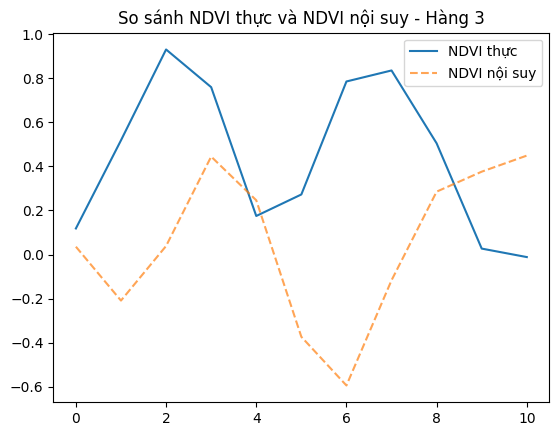

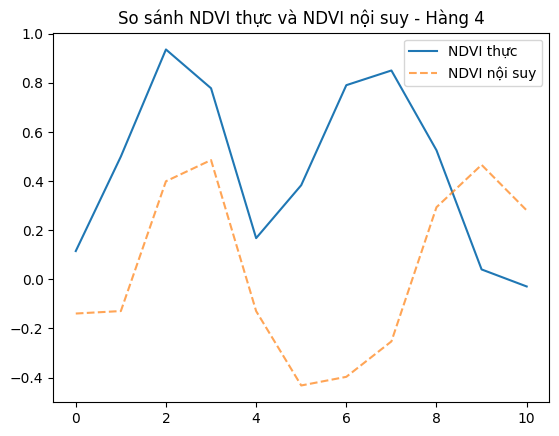

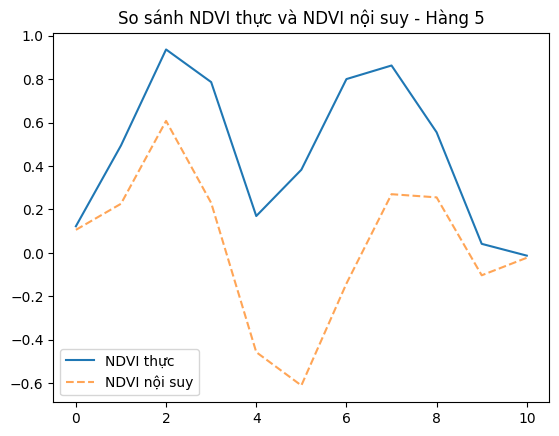

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq


# Xác định số điểm dữ liệu
N = vh_data.shape[1]  # Số cột (chuỗi thời gian)
t = np.arange(N)  # Trục thời gian giả định

# Tạo mảng lưu NDVI nội suy
ndvi_interp_data = np.zeros_like(ndvi_data)

for i in range(vh_data.shape[0]):  # Lặp qua từng hàng (chuỗi thời gian)
    vh_fft = fft(vh_data[i])
    ndvi_fft = fft(ndvi_data[i])
    freqs = fftfreq(N, (t[1] - t[0]))
    
    # Tính hệ số tỷ lệ phổ
    scale_factor = np.abs(ndvi_fft) / (np.abs(vh_fft) + 1e-6)  # Tránh chia cho 0
    ndvi_interp_fft = vh_fft * scale_factor  # Áp dụng hệ số tỷ lệ
    
    # Nghịch biến đổi Fourier để khôi phục NDVI
    ndvi_interp_data[i] = np.real(ifft(ndvi_interp_fft)) + 0.5
    
    
    # plt.plot(scale_factor)
    # plt.show()
    # Vẽ phổ Fourier
    # freqs = fftfreq(N)
    # plt.plot(freqs[:N//2], np.abs(ndvi_fft[:N//2]), label=f'NDVI row {i}')
    # plt.plot(freqs[:N//2], np.abs(vh_fft[:N//2]), label=f'VH row {i}', linestyle='dashed')
    # plt.legend()
    # plt.title(f'Phổ Fourier của hàng {i}')
    # plt.show()

    # # Vẽ so sánh NDVI thực và NDVI nội suy
    plt.plot(t, ndvi_data[i], label="NDVI thực")
    plt.plot(t, ndvi_interp_data[i], '--', label="NDVI nội suy", alpha=0.7)
    plt.legend()
    plt.title(f'So sánh NDVI thực và NDVI nội suy - Hàng {i}')
    plt.show()

# Kết quả: ndvi_interp_data chứa NDVI nội suy từ VH


Optimal bias for row 0: 0.8989898989898992


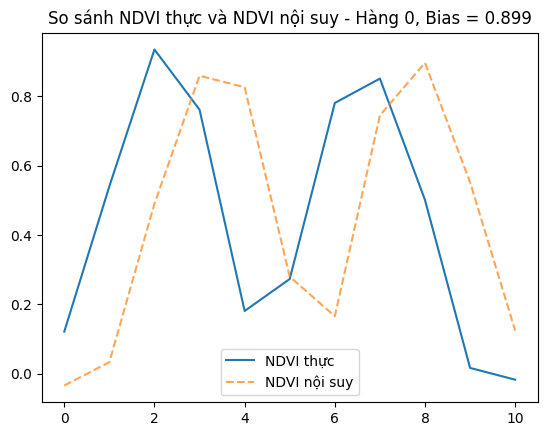

Optimal bias for row 1: 0.8989898989898992


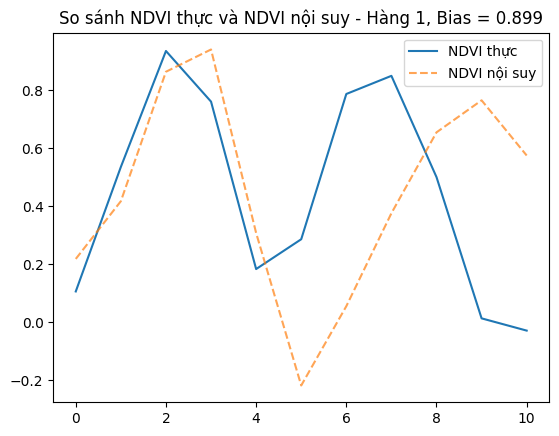

Optimal bias for row 2: 0.8989898989898992


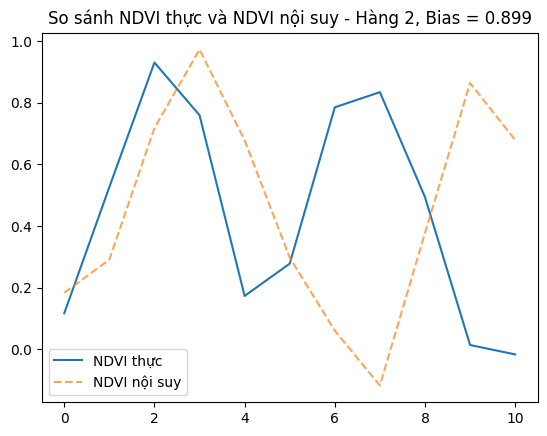

Optimal bias for row 3: 0.8989898989898992


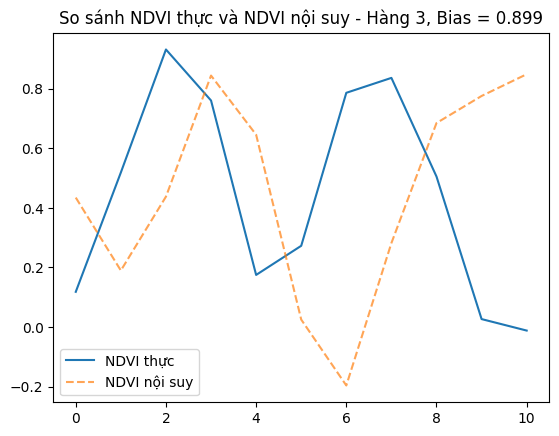

Optimal bias for row 4: 0.9191919191919193


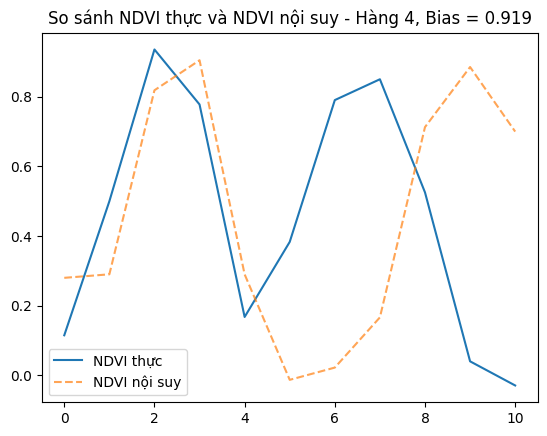

Optimal bias for row 5: 0.9393939393939394


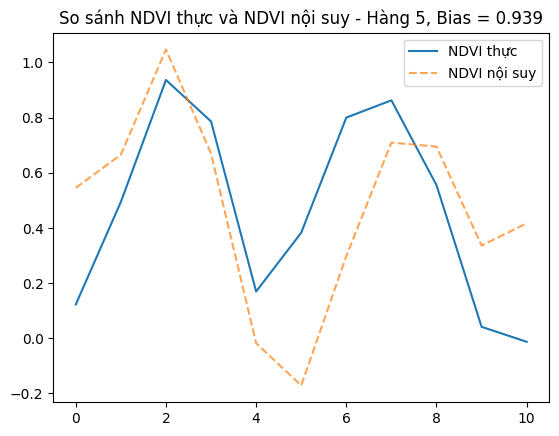

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# Giả định ndvi_data và vh_data đã được định nghĩa
N = vh_data.shape[1]
t = np.arange(N)
ndvi_interp_data = np.zeros_like(ndvi_data)

for i in range(vh_data.shape[0]):
    vh_fft = fft(vh_data[i])
    ndvi_fft = fft(ndvi_data[i])
    freqs = fftfreq(N, (t[1] - t[0]))
    
    scale_factor = np.abs(ndvi_fft) / (np.abs(vh_fft) + 1e-6)
    ndvi_interp_fft = vh_fft * scale_factor
    
    # Thử nghiệm nhiều giá trị bias
    bias_values = np.linspace(-1, 1, 100)  # Thử từ -1 đến 1
    mse_values = []
    
    for bias in bias_values:
        ndvi_interp = np.real(ifft(ndvi_interp_fft)) + bias
        mse = np.mean((ndvi_interp - ndvi_data[i])**2)  # Tính MSE
        mse_values.append(mse)
    
    # Tìm bias tối ưu
    optimal_bias = bias_values[np.argmin(mse_values)]
    print(f'Optimal bias for row {i}: {optimal_bias}')
    
    # Áp dụng bias tối ưu
    ndvi_interp_data[i] = np.real(ifft(ndvi_interp_fft)) + optimal_bias
    
    # Vẽ so sánh
    plt.plot(t, ndvi_data[i], label="NDVI thực")
    plt.plot(t, ndvi_interp_data[i], '--', label="NDVI nội suy", alpha=0.7)
    plt.legend()
    plt.title(f'So sánh NDVI thực và NDVI nội suy - Hàng {i}, Bias = {optimal_bias:.3f}')
    plt.show()